In [99]:
import numpy as np
import csv,json
import pandas as pd
# Reading DJIA index prices csv file
with open("C:/Users/85290/OneDrive - The Chinese University of Hong Kong/stat3011/DJIA_data.csv", 'rt') as csvfile:  #@@@@@@@with open('./data/DJIA_data.csv', 'rb') as csvfile:
    spamreader = csv.reader(csvfile, delimiter=',')
    # Converting the csv file reader to a lists
    data_list = list(spamreader)

# Separating header from the data
header = data_list[0]
data_list = data_list[1:]
data_list = np.asarray(data_list)
selected_data = data_list[:, [0, 1, 2, 3, 4, 5, 6]]
df = pd.DataFrame(data= selected_data[0:,1:], index=selected_data[0:,0], columns=['open','high','low','close','adjclose','volume'],dtype='float64')
# copy the data to the new dataframe df1 which is temporary dataframe
df1 = df

#idx contains all the data value between given date range
idx = pd.date_range('12-29-2006', '01-01-2017')

# Adding missing dates to the dataframe
df1.index = pd.DatetimeIndex(df1.index)
df1 = df1.reindex(idx, fill_value=np.NaN)
# Reference for pandas interpolation http://pandas.pydata.org/pandas-docs/stable/missing_data.html

interpolated_df = df1.interpolate()
#print interpolated_df.count() # gives 3656 count

# Removing extra date rows added in data for calculating interpolation
df = interpolated_df
print(len(df))
df

3657


,open,high,low,close,adjclose,volume
2006-12-29,12500.480469,12526.030273,12451.129883,12463.150391,12463.150391,161560000.0
2006-12-30,12492.292383,12536.894140,12441.867969,12465.424219,12465.424219,194688000.0
2006-12-31,12484.104297,12547.758007,12432.606055,12467.698047,12467.698047,227816000.0
2007-01-01,12475.916211,12558.621875,12423.344141,12469.971875,12469.971875,260944000.0
2007-01-02,12467.728125,12569.485742,12414.082227,12472.245703,12472.245703,294072000.0
...,...,...,...,...,...,...
2016-12-28,19964.310547,19981.109375,19827.310547,19833.679688,19833.679688,188350000.0
2016-12-29,19835.460938,19878.439453,19788.939453,19819.779297,19819.779297,172040000.0
2016-12-30,19835.460938,19878.439453,19788.939453,19819.779297,19819.779297,172040000.0
2016-12-31,19835.460938,19878.439453,19788.939453,19819.779297,19819.779297,172040000.0


In [100]:
import yfinance as yf

# Define the ticker symbol for DJIA
ticker = "^DJI"

# Fetch DJIA data
djia_data = yf.download(ticker, start="2006-01-03", end="2006-12-29")

data = djia_data.values.tolist()

index= djia_data.index[:250].date.tolist()
df0 = pd.DataFrame(data= data, index=index, columns=['open','high','low','close','adjclose','volume'],dtype='float64')
idx = pd.date_range('01-03-2006', '12-28-2006')
df0.index = pd.DatetimeIndex(df0.index)
df0 = df0.reindex(idx, fill_value=np.NaN)
interpolated_df = df0.interpolate()
df0 = interpolated_df
df0

[*********************100%%**********************]  1 of 1 completed


,open,high,low,close,adjclose,volume
2006-01-03,10718.299805,10862.780273,10684.450195,10847.410156,10847.410156,302950000.0
2006-01-04,10843.969727,10892.639648,10833.900391,10880.150391,10880.150391,271490000.0
2006-01-05,10880.389648,10908.250000,10843.650391,10882.150391,10882.150391,250910000.0
2006-01-06,10875.450195,10968.839844,10875.450195,10959.309570,10959.309570,291740000.0
2006-01-07,10903.456706,10985.943359,10898.443359,10976.839844,10976.839844,277240000.0
...,...,...,...,...,...,...
2006-12-24,12377.510254,12419.205078,12339.375000,12375.424805,12375.424805,126930000.0
2006-12-25,12359.725342,12418.702637,12338.212402,12391.527344,12391.527344,118570000.0
2006-12-26,12341.940430,12418.200195,12337.049805,12407.629883,12407.629883,110210000.0
2006-12-27,12408.429688,12519.219727,12407.790039,12510.570312,12510.570312,143650000.0


In [101]:
frames = [df0, df]
df = pd.concat(frames)
df

,open,high,low,close,adjclose,volume
2006-01-03,10718.299805,10862.780273,10684.450195,10847.410156,10847.410156,302950000.0
2006-01-04,10843.969727,10892.639648,10833.900391,10880.150391,10880.150391,271490000.0
2006-01-05,10880.389648,10908.250000,10843.650391,10882.150391,10882.150391,250910000.0
2006-01-06,10875.450195,10968.839844,10875.450195,10959.309570,10959.309570,291740000.0
2006-01-07,10903.456706,10985.943359,10898.443359,10976.839844,10976.839844,277240000.0
...,...,...,...,...,...,...
2016-12-28,19964.310547,19981.109375,19827.310547,19833.679688,19833.679688,188350000.0
2016-12-29,19835.460938,19878.439453,19788.939453,19819.779297,19819.779297,172040000.0
2016-12-30,19835.460938,19878.439453,19788.939453,19819.779297,19819.779297,172040000.0
2016-12-31,19835.460938,19878.439453,19788.939453,19819.779297,19819.779297,172040000.0


In [102]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pandas_ta as ta

In [103]:
df['EMA_10']=ta.ema(df.adjclose, length=10)
df['EMA_20']=ta.ema(df.adjclose, length=20)
df['EMA_100']=ta.ema(df.adjclose, length=100)
df['EMA_150']=ta.ema(df.adjclose, length=150)
df['HMA_10']=ta.hma(df.adjclose, length=10)
df['HMA_20']=ta.hma(df.adjclose, length=20)
df['HMA_100']=ta.hma(df.adjclose, length=100)
df['HMA_150']=ta.hma(df.adjclose, length=150)
df1=ta.ha(df.open,df.high,df.low,df.adjclose)
df2=ta.donchian(df.high,df.low,20,20)
df3=ta.hilo(df.high,df.low,df.close,13,21)
df4=ta.accbands(df.high,df.low,df.close,length=20)
df5=ta.bbands(df.adjclose,length=5)
df6=ta.aberration(df.high,df.low,df.close,5,15)
df= pd.concat([df,df1,df2,df3,df4], axis=1)
df['LDECAY']=ta.decay(df.adjclose)
df['LR']=ta.log_return(df.adjclose,length=14)
df['ALMA']=ta.alma(df.adjclose,10,6.0,0.85)

C:\Users\85290\AppData\Local\Temp\ipykernel_14196\994391291.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df1=ta.ha(df.open,df.high,df.low,df.adjclose)
c:\Users\85290\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas_ta\candles\ha.py:25: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = v

In [104]:
df

,open,high,low,close,adjclose,volume,EMA_10,EMA_20,EMA_100,EMA_150,...,DCU_20_20,HILO_13_21,HILOl_13_21,HILOs_13_21,ACCBL_20,ACCBM_20,ACCBU_20,LDECAY,LR,ALMA
2006-01-03,10718.299805,10862.780273,10684.450195,10847.410156,10847.410156,302950000.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10847.410156,NaN,NaN
2006-01-04,10843.969727,10892.639648,10833.900391,10880.150391,10880.150391,271490000.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10880.150391,NaN,NaN
2006-01-05,10880.389648,10908.250000,10843.650391,10882.150391,10882.150391,250910000.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10882.150391,NaN,NaN
2006-01-06,10875.450195,10968.839844,10875.450195,10959.309570,10959.309570,291740000.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10959.309570,NaN,NaN
2006-01-07,10903.456706,10985.943359,10898.443359,10976.839844,10976.839844,277240000.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10976.839844,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-12-28,19964.310547,19981.109375,19827.310547,19833.679688,19833.679688,188350000.0,19896.420090,19796.876519,19017.391805,18777.333198,...,19987.630859,19717.038807,19717.038807,19717.038807,19655.002383,19874.087256,20096.933291,19944.839063,0.002077,19934.406807
2016-12-29,19835.460938,19878.439453,19788.939453,19819.779297,19819.779297,172040000.0,19882.485400,19799.057736,19033.280666,18791.140431,...,19987.630859,19717.038807,19717.038807,19717.038807,19667.769183,19877.233740,20098.437396,19833.479688,-0.001636,19940.688964
2016-12-30,19835.460938,19878.439453,19788.939453,19819.779297,19819.779297,172040000.0,19871.084291,19801.031218,19048.854897,18804.764787,...,19987.630859,19943.795523,NaN,19943.795523,19676.549023,19879.720557,20100.762972,19819.779297,-0.001192,19932.491335
2016-12-31,19835.460938,19878.439453,19788.939453,19819.779297,19819.779297,172040000.0,19861.756110,19802.816749,19064.120726,18818.208688,...,19987.630859,19940.631160,NaN,19940.631160,19681.339990,19881.547705,20103.908106,19819.779297,-0.001857,19932.775150


In [105]:
interpolated_df = df.interpolate()
interpolated_df

,open,high,low,close,adjclose,volume,EMA_10,EMA_20,EMA_100,EMA_150,...,DCU_20_20,HILO_13_21,HILOl_13_21,HILOs_13_21,ACCBL_20,ACCBM_20,ACCBU_20,LDECAY,LR,ALMA
2006-01-03,10718.299805,10862.780273,10684.450195,10847.410156,10847.410156,302950000.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10847.410156,NaN,NaN
2006-01-04,10843.969727,10892.639648,10833.900391,10880.150391,10880.150391,271490000.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10880.150391,NaN,NaN
2006-01-05,10880.389648,10908.250000,10843.650391,10882.150391,10882.150391,250910000.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10882.150391,NaN,NaN
2006-01-06,10875.450195,10968.839844,10875.450195,10959.309570,10959.309570,291740000.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10959.309570,NaN,NaN
2006-01-07,10903.456706,10985.943359,10898.443359,10976.839844,10976.839844,277240000.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10976.839844,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-12-28,19964.310547,19981.109375,19827.310547,19833.679688,19833.679688,188350000.0,19896.420090,19796.876519,19017.391805,18777.333198,...,19987.630859,19717.038807,19717.038807,19717.038807,19655.002383,19874.087256,20096.933291,19944.839063,0.002077,19934.406807
2016-12-29,19835.460938,19878.439453,19788.939453,19819.779297,19819.779297,172040000.0,19882.485400,19799.057736,19033.280666,18791.140431,...,19987.630859,19717.038807,19717.038807,19717.038807,19667.769183,19877.233740,20098.437396,19833.479688,-0.001636,19940.688964
2016-12-30,19835.460938,19878.439453,19788.939453,19819.779297,19819.779297,172040000.0,19871.084291,19801.031218,19048.854897,18804.764787,...,19987.630859,19943.795523,19717.038807,19943.795523,19676.549023,19879.720557,20100.762972,19819.779297,-0.001192,19932.491335
2016-12-31,19835.460938,19878.439453,19788.939453,19819.779297,19819.779297,172040000.0,19861.756110,19802.816749,19064.120726,18818.208688,...,19987.630859,19940.631160,19717.038807,19940.631160,19681.339990,19881.547705,20103.908106,19819.779297,-0.001857,19932.775150


In [106]:
df= interpolated_df[363:]
df

,open,high,low,close,adjclose,volume,EMA_10,EMA_20,EMA_100,EMA_150,...,DCU_20_20,HILO_13_21,HILOl_13_21,HILOs_13_21,ACCBL_20,ACCBM_20,ACCBU_20,LDECAY,LR,ALMA
2007-01-01,12475.916211,12558.621875,12423.344141,12469.971875,12469.971875,260944000.0,12451.004005,12420.044302,12125.293014,11959.184740,...,12558.621875,12355.651181,12355.651181,12355.651181,12228.978621,12430.986836,12643.542780,12469.971875,0.002304,12396.002743
2007-01-02,12467.728125,12569.485742,12414.082227,12472.245703,12472.245703,294072000.0,12454.866132,12425.015864,12132.163364,11965.980250,...,12569.485742,12355.651181,12355.651181,12355.651181,12225.847921,12438.724121,12662.500264,12472.245703,0.000074,12423.330825
2007-01-03,12459.540039,12580.349609,12404.820313,12474.519531,12474.519531,327200000.0,12458.439477,12429.730499,12138.942694,11972.715869,...,12580.349609,12355.651181,12355.651181,12355.651181,12225.671428,12441.612109,12675.143595,12474.519531,0.000854,12452.662885
2007-01-04,12473.160156,12510.410156,12403.860352,12480.690430,12480.690430,259060000.0,12462.485105,12434.583826,12145.709976,11979.444009,...,12580.349609,12355.651181,12355.651181,12355.651181,12221.184234,12443.370654,12680.188872,12480.690430,0.004774,12475.028661
2007-01-05,12480.049805,12480.129883,12365.410156,12398.009766,12398.009766,235220000.0,12450.762316,12431.100582,12150.706011,11984.987927,...,12580.349609,12508.837477,12432.244329,12508.837477,12213.559796,12441.065999,12684.694398,12480.490430,0.004429,12483.840577
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-12-28,19964.310547,19981.109375,19827.310547,19833.679688,19833.679688,188350000.0,19896.420090,19796.876519,19017.391805,18777.333198,...,19987.630859,19717.038807,19717.038807,19717.038807,19655.002383,19874.087256,20096.933291,19944.839063,0.002077,19934.406807
2016-12-29,19835.460938,19878.439453,19788.939453,19819.779297,19819.779297,172040000.0,19882.485400,19799.057736,19033.280666,18791.140431,...,19987.630859,19717.038807,19717.038807,19717.038807,19667.769183,19877.233740,20098.437396,19833.479688,-0.001636,19940.688964
2016-12-30,19835.460938,19878.439453,19788.939453,19819.779297,19819.779297,172040000.0,19871.084291,19801.031218,19048.854897,18804.764787,...,19987.630859,19943.795523,19717.038807,19943.795523,19676.549023,19879.720557,20100.762972,19819.779297,-0.001192,19932.491335
2016-12-31,19835.460938,19878.439453,19788.939453,19819.779297,19819.779297,172040000.0,19861.756110,19802.816749,19064.120726,18818.208688,...,19987.630859,19940.631160,19717.038807,19940.631160,19681.339990,19881.547705,20103.908106,19819.779297,-0.001857,19932.775150


In [107]:
df['Target'] = df['adjclose']-df['open']
df['Target'] = df['Target'].shift(-1)
df['TargetClass'] = [1 if df.Target[i]>0 else -1 for i in range(len(df))]
df['TargetNextClose'] = df['adjclose'].shift(-1)
df = df.drop(df.index[-1])
df = df.drop('close', axis=1)
df

C:\Users\85290\AppData\Local\Temp\ipykernel_14196\2673100601.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Target'] = df['adjclose']-df['open']
C:\Users\85290\AppData\Local\Temp\ipykernel_14196\2673100601.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Target'] = df['Target'].shift(-1)
C:\Users\85290\AppData\Local\Temp\ipykernel_14196\2673100601.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labe

,open,high,low,adjclose,volume,EMA_10,EMA_20,EMA_100,EMA_150,HMA_10,...,HILOs_13_21,ACCBL_20,ACCBM_20,ACCBU_20,LDECAY,LR,ALMA,Target,TargetClass,TargetNextClose
2007-01-01,12475.916211,12558.621875,12423.344141,12469.971875,260944000.0,12451.004005,12420.044302,12125.293014,11959.184740,12487.570377,...,12355.651181,12228.978621,12430.986836,12643.542780,12469.971875,0.002304,12396.002743,4.517578,1,12472.245703
2007-01-02,12467.728125,12569.485742,12414.082227,12472.245703,294072000.0,12454.866132,12425.015864,12132.163364,11965.980250,12477.658904,...,12355.651181,12225.847921,12438.724121,12662.500264,12472.245703,0.000074,12423.330825,14.979492,1,12474.519531
2007-01-03,12459.540039,12580.349609,12404.820313,12474.519531,327200000.0,12458.439477,12429.730499,12138.942694,11972.715869,12473.206532,...,12355.651181,12225.671428,12441.612109,12675.143595,12474.519531,0.000854,12452.662885,7.530274,1,12480.690430
2007-01-04,12473.160156,12510.410156,12403.860352,12480.690430,259060000.0,12462.485105,12434.583826,12145.709976,11979.444009,12474.216013,...,12355.651181,12221.184234,12443.370654,12680.188872,12480.690430,0.004774,12475.028661,-82.040039,-1,12398.009766
2007-01-05,12480.049805,12480.129883,12365.410156,12398.009766,235220000.0,12450.762316,12431.100582,12150.706011,11984.987927,12457.243584,...,12508.837477,12213.559796,12441.065999,12684.694398,12480.490430,0.004429,12483.840577,-44.199870,-1,12406.503255
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-12-27,19943.460938,19980.240234,19939.800781,19945.039063,158540000.0,19910.362401,19793.002501,19000.901141,18763.154050,19944.505814,...,19717.038807,19641.682747,19863.143799,20079.449105,19945.039063,0.001698,19918.118016,-130.630859,-1,19833.679688
2016-12-28,19964.310547,19981.109375,19827.310547,19833.679688,188350000.0,19896.420090,19796.876519,19017.391805,18777.333198,19918.674091,...,19717.038807,19655.002383,19874.087256,20096.933291,19944.839063,0.002077,19934.406807,-15.681641,-1,19819.779297
2016-12-29,19835.460938,19878.439453,19788.939453,19819.779297,172040000.0,19882.485400,19799.057736,19033.280666,18791.140431,19877.715249,...,19717.038807,19667.769183,19877.233740,20098.437396,19833.479688,-0.001636,19940.688964,-15.681641,-1,19819.779297
2016-12-30,19835.460938,19878.439453,19788.939453,19819.779297,172040000.0,19871.084291,19801.031218,19048.854897,18804.764787,19836.642789,...,19943.795523,19676.549023,19879.720557,20100.762972,19819.779297,-0.001192,19932.491335,-15.681641,-1,19819.779297


In [108]:
def train_test_split(data, perc):
  data = data.values
  n = int(len(data) *(1 - perc))
  return data[:n], data[n:]
train, test = train_test_split(df, 0.2)
train

X = train[:,:-1]
y = train[:,-1]

from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

params = { 'max_depth': [2],
           'learning_rate': [0.05],
           'n_estimators': [650],
           'colsample_bytree': [0.7]}

xgbr = XGBRegressor(seed = 20) 
modl = GridSearchCV(estimator=xgbr, 
                   param_grid=params,
                   scoring='neg_mean_squared_error', 
                   verbose=1)
modl.fit(X,y)
print("Best parameters:", modl.best_params_)
print("Lowest RMSE: ", (-modl.best_score_)**(1/2.0))



Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best parameters: {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 650}
Lowest RMSE:  776.3372696069283


In [109]:
from xgboost import XGBRegressor
model = XGBRegressor(objective='reg:squarederror',  n_estimators=650, learning_rate=0.05, colsample_bytree=0.7,max_depth=2,gamma=5)
model.fit(X,y)
val = np.array(test[0,:-1]).reshape(1,-1)
pred = model.predict(val)
pred


array([17917.838], dtype=float32)

Best parameters: {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 650}
Lowest RMSE:  776.3372696069283
RMSE:69.38701070200055
MAPE:0.27990058403559115
[17832.990234   17722.54361967 17612.09700533 17501.650391
 17371.640625   17584.519531   17907.869141   17737.369141
 17705.19270867 17673.01627633 17640.839844   17613.679688
 17427.089844   17320.710938   17511.570313   17512.485352
 17513.400391   17514.31543    17515.230469   17554.279297
 17813.980469   17672.599609   17674.63281233 17676.66601567
 17678.699219   17387.210938   17191.369141   17416.849609
 17164.949219   17230.31250033 17295.67578167 17361.039063
 17666.400391   17673.019531   17884.880859   17824.289063
 17792.59635467 17760.90364633 17729.210938   17868.759766
 17862.140625   17972.380859   18019.349609   18026.40722625
 18033.4648435  18040.52246075 18047.580078   18029.849609
 17985.769531   18140.439453   18132.57291667 18124.70638033
 18116.839844   18209.189453   18224.570313 

c:\Users\85290\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


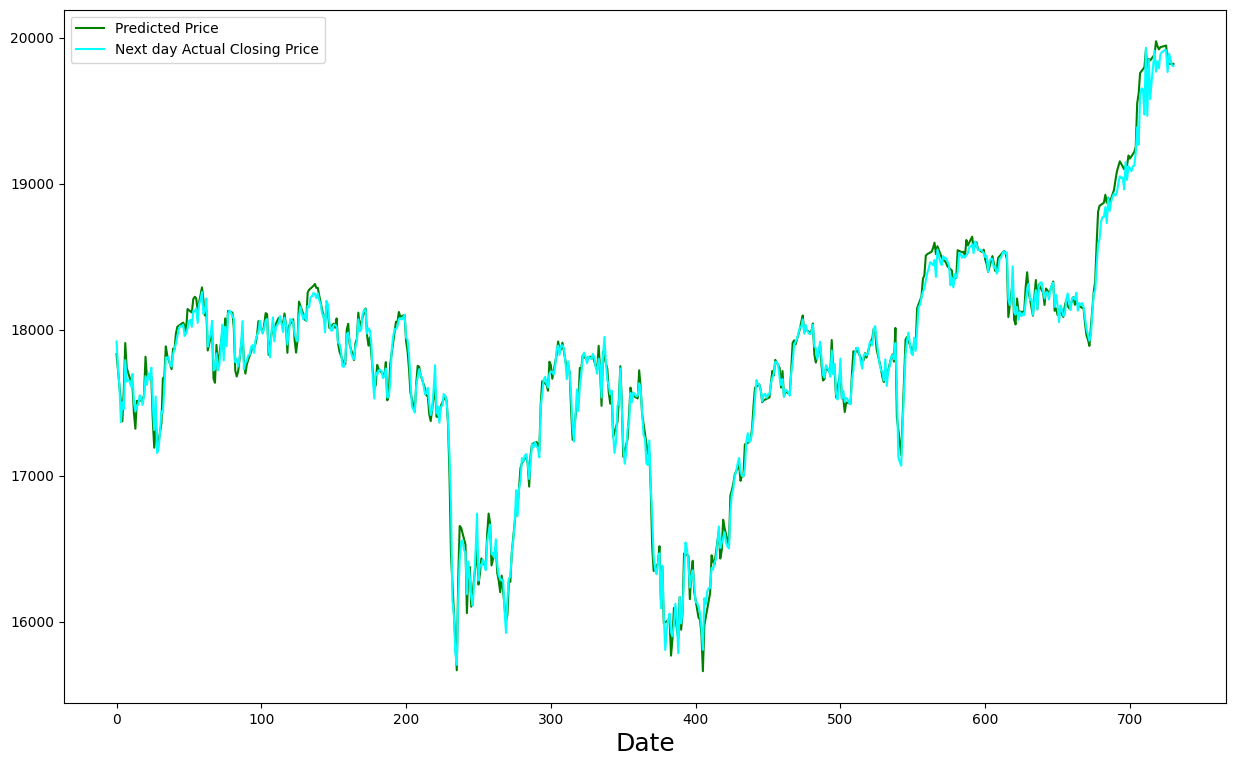

In [110]:
def xgb_predict(train, val):
  train = np.array(train)
  X, y = train[:, :-1], train[:,-1]
  model = XGBRegressor(objective='reg:squarederror',   n_estimators=650, learning_rate=0.05, colsample_bytree=0.7,max_depth=2,gamma=5)
  model.fit(X,y)
  val = np.array(val).reshape(1, -1)
  pred = model.predict(val)
  return pred[0]

xgb_predict(train,test[0,:-1])
print("Best parameters:", modl.best_params_)
print("Lowest RMSE: ", (-modl.best_score_)**(1/2.0))

xgb_predict(train,test[0,:-1])

def mape(actual, pred):
  actual, pred = np.array(actual), np.array(pred)
  mape = np.mean(np.abs((actual-pred)/actual))*100
  return mape

from sklearn.metrics import mean_squared_error

def validate(data, perc):
  predictions = []
  train, test = train_test_split(data, perc)
  history = [x for x in train]

  for i in range(len(test)):
    X_test, y_test = test[i, :-1], test[i, -1]
    pred = xgb_predict(history, X_test)
    predictions.append(pred)

    history.append(test[i])

  error = mean_squared_error(test[:, -1], predictions, squared=False) 
  MAPE = mape(test[:,-1], predictions)
  return error, MAPE, test[:, -1], predictions

rmse,MAPE,y,pred=validate(df,0.2)

print("RMSE:" f'{rmse}')
print("MAPE:" f'{MAPE}')
print(y)
print(pred)

pred = np.array(pred)
test_pred = np.c_[test,pred]

df_TP=pd.DataFrame(test_pred)
df_TP.head()

plt.figure(figsize= (15,9))
plt.plot(df_TP.iloc[:, -2:-1], label="Predicted Price", color='green')
plt.plot(df_TP.iloc[:,-1], label="Next day Actual Closing Price", color='cyan')
plt.xlabel('Date', fontsize = 18)
plt.legend(loc= "upper left")

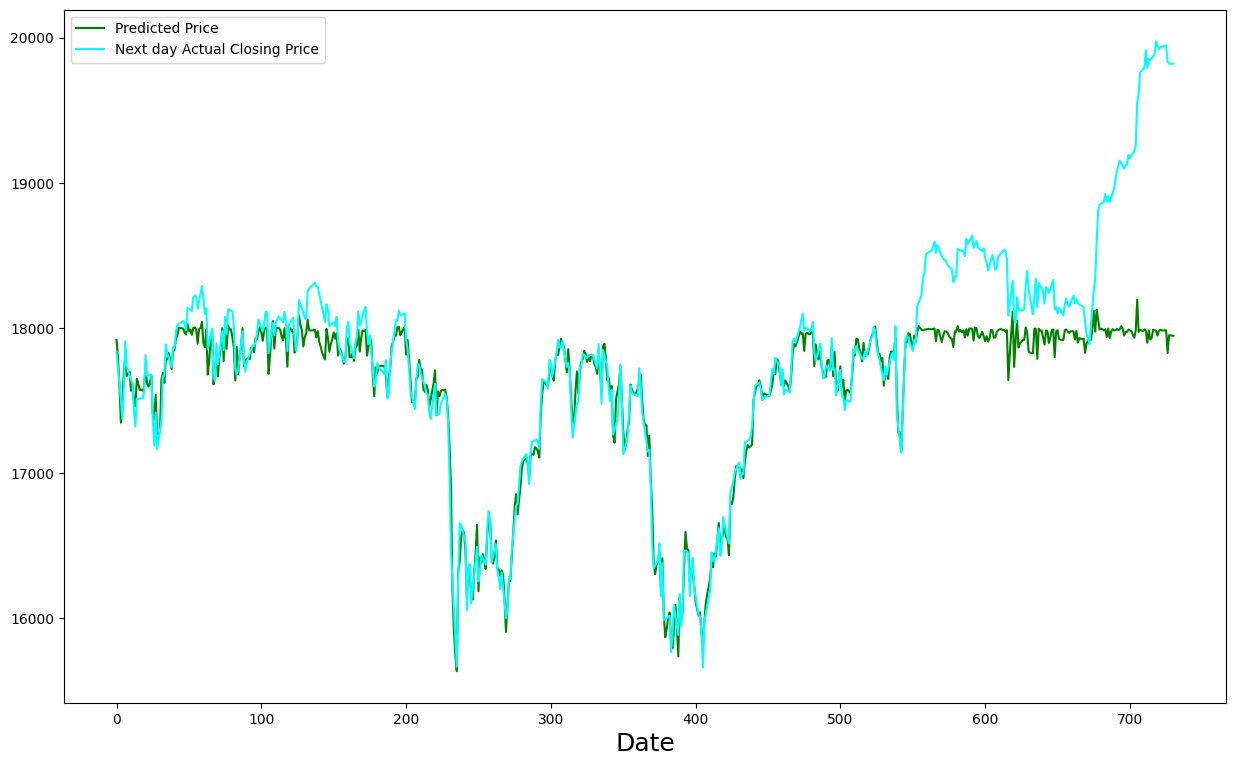

In [111]:
train, test = train_test_split(df, 0.2)
train

X = train[:,:-1]
y = train[:,-1]

X, y = train[:, :-1], train[:,-1]
model.fit(X,y)

X_test = test[:,:-1]
y_test = test[:,-1]
y_pred=model.predict(X_test)
plt.figure(figsize= (15,9))
plt.plot(y_pred, label="Predicted Price", color='green')
plt.plot(y_test, label="Next day Actual Closing Price", color='cyan')
plt.xlabel('Date', fontsize = 18)
plt.legend(loc= "upper left")

In [112]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
r2 = r2_score(y_pred,y_test)
mse = mean_squared_error(y_pred,y_test)
mae = mean_absolute_error(y_pred,y_test)
print("R-squared:", r2)
print("mean_squared_error:", mse)
print("mean_absolute_error:", mae)

R-squared: 0.3723051332232681
mean_squared_error: 203139.39982952416
mean_absolute_error: 223.00062966809176


In [113]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
r2 = r2_score(df_TP.iloc[:,-1],df_TP.iloc[:, -2:-1])
mse = mean_squared_error(df_TP.iloc[:,-1],df_TP.iloc[:, -2:-1])
mae = mean_absolute_error(df_TP.iloc[:,-1],df_TP.iloc[:, -2:-1])
print("R-squared:", r2)
print("mean_squared_error:", mse)
print("mean_absolute_error:", mae)

R-squared: 0.9920633164784725
mean_squared_error: 4814.557254159539
mean_absolute_error: 49.64569840381328


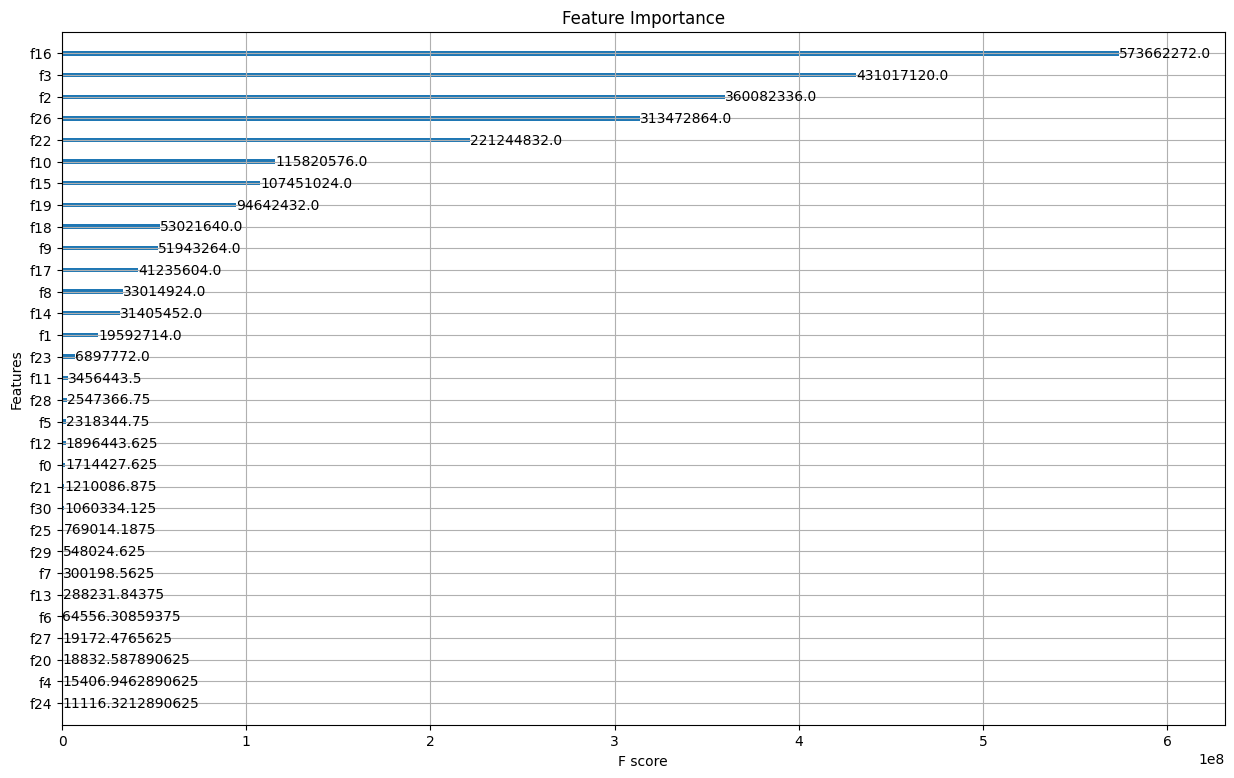

In [114]:
import xgboost as xgb
# Plot feature importance using Matplotlib
fig, ax = plt.subplots(figsize=(15, 9) )
xgb.plot_importance(model, ax=ax, importance_type='gain')
plt.title('Feature Importance')
plt.show()

In [115]:
column_names_list = df.columns.tolist()
print(column_names_list)
print(column_names_list[16])
print(column_names_list[3])
print(column_names_list[25])
print(column_names_list[2])
print(column_names_list[14])
print(column_names_list[17])
print(column_names_list[10])
print(column_names_list[1])
print(column_names_list[15])
print(column_names_list[22])
print(column_names_list[9])
print(column_names_list[19])
print(column_names_list[8])
print(column_names_list[23])
print(column_names_list[18])
print(column_names_list[7])


['open', 'high', 'low', 'adjclose', 'volume', 'EMA_10', 'EMA_20', 'EMA_100', 'EMA_150', 'HMA_10', 'HMA_20', 'HMA_100', 'HMA_150', 'HA_open', 'HA_high', 'HA_low', 'HA_close', 'DCL_20_20', 'DCM_20_20', 'DCU_20_20', 'HILO_13_21', 'HILOl_13_21', 'HILOs_13_21', 'ACCBL_20', 'ACCBM_20', 'ACCBU_20', 'LDECAY', 'LR', 'ALMA', 'Target', 'TargetClass', 'TargetNextClose']
HA_close
adjclose
ACCBU_20
low
HA_high
DCL_20_20
HMA_20
high
HA_low
HILOs_13_21
HMA_10
DCU_20_20
EMA_150
ACCBL_20
DCM_20_20
EMA_100
